# Full Simulated 3D Scanner Pipeline

Acquisition, laser stripe extraction, point cloud reconstruction, Poisson meshing, Blender OBJ export, and Chamfer Distance.

In [1]:
%pip install opencv-python matplotlib open3d


  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached dash-4.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached werkzeug-3.0.6-py3-none-any.whl.metadata (3.7 kB)
  Using cached flask-3.0.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached configargparse-1.7.5-py3-none-any.whl.metadata (23 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
  Using cached blinker-1.8.2-py3-none-any.whl.metadata (1.6 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
   ---------------------------------------- 0.0/69.2 MB ? eta -:--:--
   - -------------------------------------- 2.4/69.2 MB 13.4 MB/s eta 0:00:05
   ---- ----------------------------------- 7.1/69.2 MB 18.2 MB/s eta 0:00:04
   ------ --------------------------------

In [2]:
from pathlib import Path
import json
import subprocess
import sys

try:
    import cv2
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    import numpy as np
    import open3d as o3d
except ImportError as exc:
    raise ImportError("Install notebook dependencies: pip install opencv-python matplotlib open3d") from exc

from reconstruct import (
    align_by_bbox,
    export_mesh,
    reconstruct,
    reconstruct_surface,
    sample_mesh,
    save_ply,
    validate_reconstruction,
)

ROOT = Path.cwd()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)

dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

print(f"Dataset: {dataset_name}")


def point_cloud_from_array(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    return pcd


def plot_points(points, title, limit=12000):
    if len(points) == 0:
        raise ValueError("No points to plot")

    count = min(limit, len(points))
    sample = points[np.linspace(0, len(points) - 1, count).astype(int)]

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(sample[:, 0], sample[:, 1], sample[:, 2], s=1)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    extent = np.ptp(sample, axis=0)
    if np.all(extent > 0):
        ax.set_box_aspect(extent)

    plt.tight_layout()


def plot_mesh(mesh, title, max_triangles=8000):
    verts = np.asarray(mesh.vertices)
    tris = np.asarray(mesh.triangles)

    if len(tris) > max_triangles:
        rng = np.random.default_rng(0)
        tris = tris[rng.choice(len(tris), max_triangles, replace=False)]

    tri_verts = verts[tris]  # (N, 3, 3)

    # per-face normal for simple diffuse shading
    e1 = tri_verts[:, 1] - tri_verts[:, 0]
    e2 = tri_verts[:, 2] - tri_verts[:, 0]
    normals = np.cross(e1, e2)
    norms = np.linalg.norm(normals, axis=1, keepdims=True)
    normals /= np.where(norms > 0, norms, 1)

    light = np.array([0.5, 0.5, 1.0])
    light /= np.linalg.norm(light)
    intensity = np.clip(normals @ light, 0, 1) * 0.6 + 0.35
    colors = plt.cm.Blues_r(intensity)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    poly = Poly3DCollection(tri_verts, facecolors=colors, linewidth=0, alpha=1.0)
    ax.add_collection3d(poly)

    lo, hi = verts.min(axis=0), verts.max(axis=0)
    ax.set_xlim(lo[0], hi[0])
    ax.set_ylim(lo[1], hi[1])
    ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect(hi - lo)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.tight_layout()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Dataset: asteroid


## 1. Acquisition Frames

render dir: c:\Users\pb00441\ComputerVision\scanner_renders_asteroid
frames:     36 / 36


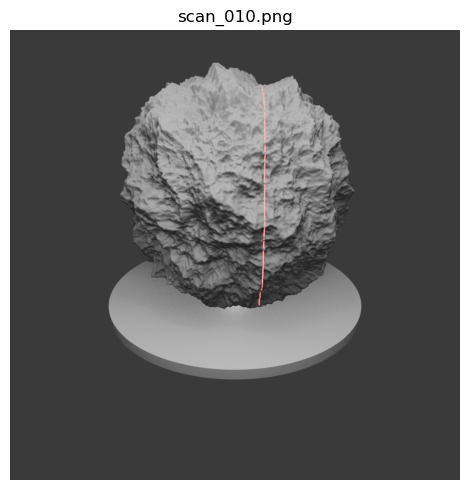

In [3]:
render_dir = ROOT / paths["input_dir"]
renders = sorted(render_dir.glob("scan_*.png"))

print(f"render dir: {render_dir}")
print(f"frames:     {len(renders)} / {config['disk']['n_frames']}")

assert renders, f"No rendered frames found in {render_dir}"

frame = min(10, len(renders) - 1)
image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(renders[frame].name)
plt.axis("off")
plt.tight_layout()

## 2. Laser Stripe Extraction

masks:  36
coords: 36
stripe points per frame: min 459  mean 493.8  max 529


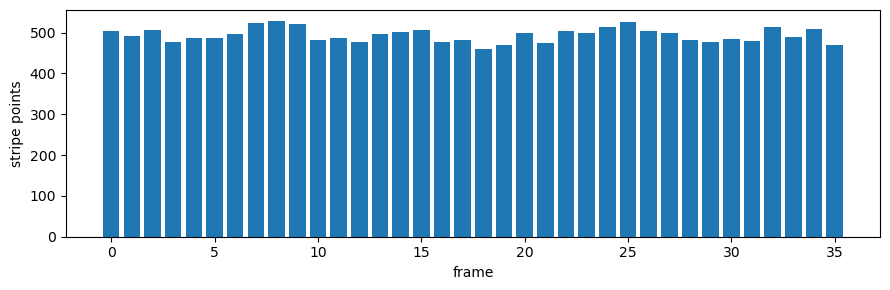

In [4]:
subprocess.run([sys.executable, "extract_stripes.py"], cwd=ROOT, check=True)

masks = sorted((ROOT / paths["stripe_masks_dir"]).glob("scan_*.png"))
coords = sorted((ROOT / paths["stripe_coords_dir"]).glob("scan_*.npy"))
counts = np.array([len(np.load(path)) for path in coords])

print(f"masks:  {len(masks)}")
print(f"coords: {len(coords)}")
print(f"stripe points per frame: min {counts.min()}  mean {counts.mean():.1f}  max {counts.max()}")

plt.figure(figsize=(9, 3))
plt.bar(range(len(counts)), counts)
plt.xlabel("frame")
plt.ylabel("stripe points")
plt.tight_layout()

## 3. Centerline Check

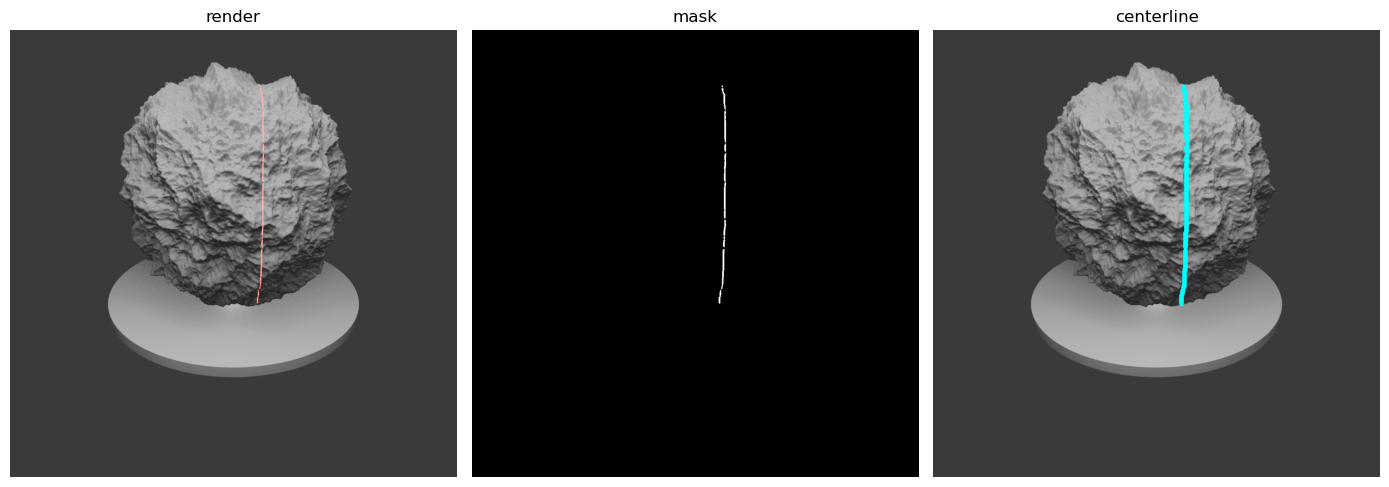

In [5]:
frame = min(10, len(renders) - 1)

image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)
mask = cv2.imread(str(masks[frame]), cv2.IMREAD_GRAYSCALE)
centerline = np.load(coords[frame])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("render")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("mask")
axes[2].imshow(image)
axes[2].scatter(centerline[:, 1], centerline[:, 0], s=3, c="cyan")
axes[2].set_title("centerline")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

## 4. Point Cloud Reconstruction

points: 17777
saved:  c:\Users\pb00441\ComputerVision\point_cloud_asteroid.ply
min:    [-1.6570183  -1.6021515   0.13473138]
max:    [1.6881986 1.6080037 3.4655094]
mean:   [2.1664961e-03 3.5044195e-03 2.1766355e+00]


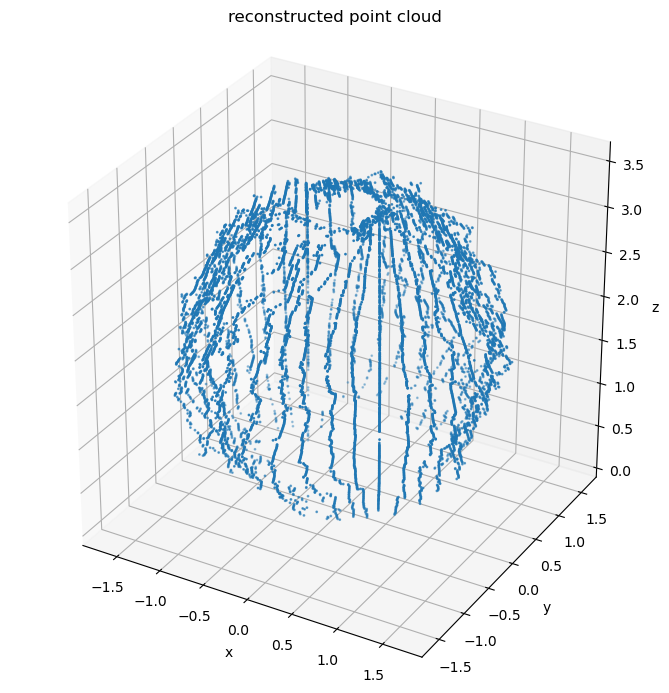

In [6]:
points = reconstruct(config)
point_cloud_path = ROOT / paths["point_cloud"]
save_ply(points, point_cloud_path)

print(f"points: {len(points)}")
print(f"saved:  {point_cloud_path}")
print(f"min:    {points.min(axis=0)}")
print(f"max:    {points.max(axis=0)}")
print(f"mean:   {points.mean(axis=0)}")

plot_points(points, "reconstructed point cloud")

## 5. Poisson Surface Reconstruction and Blender Export

[Open3D WARNING] Write OBJ can not include triangle normals.
mesh vertices:  61058
mesh triangles: 121575
saved PLY:      C:\Users\pb00441\ComputerVision\mesh_asteroid.ply

Blender OBJ →   C:\Users\pb00441\ComputerVision\blender\mesh_asteroid.obj
  In Blender: File > Import > Wavefront (.obj), select that file.


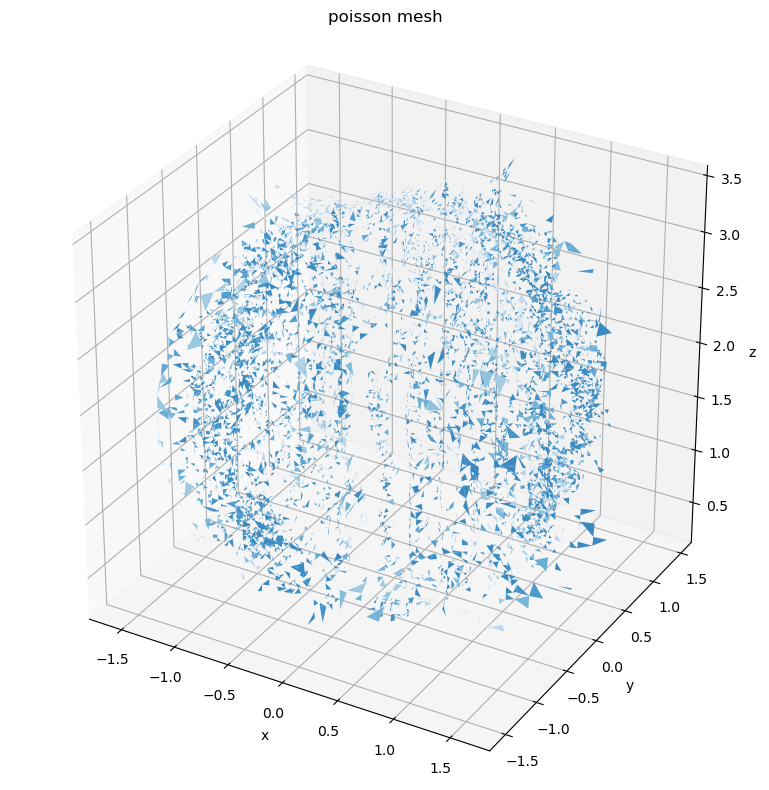

In [7]:
mesh_path = ROOT / paths["reconstructed_mesh"]
mesh_obj_path = ROOT / paths.get(
    "reconstructed_mesh_obj",
    Path(paths["reconstructed_mesh"]).with_suffix(".obj").name,
)

mesh = reconstruct_surface(points, str(mesh_path))
export_mesh(mesh, str(mesh_obj_path))

print(f"mesh vertices:  {len(mesh.vertices)}")
print(f"mesh triangles: {len(mesh.triangles)}")
print(f"saved PLY:      {mesh_path.resolve()}")
print()
print(f"Blender OBJ →   {mesh_obj_path.resolve()}")
print("  In Blender: File > Import > Wavefront (.obj), select that file.")

plot_mesh(mesh, "poisson mesh")

## 6. Chamfer Distance

{
  "reconstruction_to_ground_truth_mean": 0.15029709611679976,
  "ground_truth_to_reconstruction_mean": 0.09522715654046243,
  "chamfer_l1_mean": 0.1227621263286311,
  "chamfer_l2_mean": 0.026804940122352038,
  "reconstruction_to_ground_truth_p95": 0.4108478107850776,
  "ground_truth_to_reconstruction_p95": 0.25338997590618073,
  "dataset": "asteroid",
  "sample_count": 30000,
  "ground_truth_aligned_by_bbox": true
}
saved: c:\Users\pb00441\ComputerVision\metrics_asteroid.json


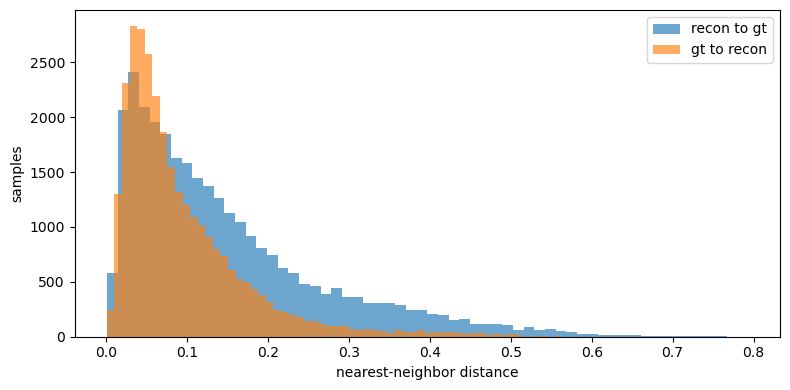

In [8]:
mesh_path = ROOT / paths["reconstructed_mesh"]
ground_truth_path = ROOT / paths["ground_truth_mesh"]
metrics_path = ROOT / paths["metrics"]

sample_count = 30000

if not ground_truth_path.exists():
    print(f"Missing ground truth mesh: {ground_truth_path}")
    print("Export the original Blender object to that path, then rerun this cell.")
else:
    metrics = validate_reconstruction(config, dataset_name, sample_count=sample_count)

    o3d.utility.random.seed(42)
    reconstruction_sample = sample_mesh(str(mesh_path), sample_count)
    ground_truth_sample = sample_mesh(str(ground_truth_path), sample_count)
    ground_truth_sample = align_by_bbox(ground_truth_sample, reconstruction_sample)

    d_recon_gt = np.asarray(reconstruction_sample.compute_point_cloud_distance(ground_truth_sample))
    d_gt_recon = np.asarray(ground_truth_sample.compute_point_cloud_distance(reconstruction_sample))

    print(json.dumps(metrics, indent=2))
    print(f"saved: {metrics_path}")

    plt.figure(figsize=(8, 4))
    plt.hist(d_recon_gt, bins=60, alpha=0.65, label="recon to gt")
    plt.hist(d_gt_recon, bins=60, alpha=0.65, label="gt to recon")
    plt.xlabel("nearest-neighbor distance")
    plt.ylabel("samples")
    plt.legend()
    plt.tight_layout()